In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Carregar a nossa base consolidada
df = pd.read_csv(r'..\data\processed\dados_consolidados_b3.csv')
df.head()

#usando os clusters que fizemos no 7

df_clusters = pd.read_csv(r'..\data\processed\clusters_empresas.csv')
df = df.merge(df_clusters, on='TICKER', how='left')


In [2]:
df = df.sort_values(by=['TICKER', 'ANO']).reset_index(drop=True)

In [3]:
df.head(10)

,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO,CLUSTER,PERFIL
0,2021,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,49.708982,84.017617,0.591650,2021-12-31,12.24,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.)
1,2022,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,56.027746,83.327827,0.672377,2022-12-31,12.13,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.)
2,2023,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.703500,80.143802,0.744955,2023-12-31,12.07,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.)
3,2024,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.614822,99.580514,0.598660,2024-12-31,10.89,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.)
4,2025,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,61.670770,88.774781,0.694688,2025-12-31,13.82,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.)
5,2021,BR MALLS PARTICIPACOES S.A.,ALOS3.SA,Emp. Adm. Part. - Comércio (Atacado e Varejo),-0.248118,11.239247,-0.022076,2021-12-31,16.30,0.0,Cluster 0: Blue Chips & Sólidas (+23% a.a.)
6,2022,BR MALLS PARTICIPACOES S.A.,ALOS3.SA,Emp. Adm. Part. - Comércio (Atacado e Varejo),1.681068,11.265549,0.149222,2022-12-31,13.04,0.0,Cluster 0: Blue Chips & Sólidas (+23% a.a.)
7,2023,BR MALLS PARTICIPACOES S.A.,ALOS3.SA,Emp. Adm. Part. - Comércio (Atacado e Varejo),7.901460,13.132195,0.601686,2023-12-31,20.94,0.0,Cluster 0: Blue Chips & Sólidas (+23% a.a.)
8,2024,ALLOS S.A.,ALOS3.SA,Emp. Adm. Part. - Comércio (Atacado e Varejo),8.611776,14.134520,0.609273,2024-12-31,15.59,0.0,Cluster 0: Blue Chips & Sólidas (+23% a.a.)
9,2025,ALLOS S.A.,ALOS3.SA,Emp. Adm. Part. - Comércio (Atacado e Varejo),3.514542,13.899006,0.252863,2025-12-31,26.14,0.0,Cluster 0: Blue Chips & Sólidas (+23% a.a.)


In [4]:
df['ROE_PROX_ANO'] = df.groupby('TICKER')['ROE'].shift(-1)

In [5]:
df.head()
#O ROE 2026 é o que iremos tentar prever, no caso não o valor e sim se vai subir ou descer

,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO,CLUSTER,PERFIL,ROE_PROX_ANO
0,2021,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,49.708982,84.017617,0.591650,2021-12-31,12.24,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.672377
1,2022,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,56.027746,83.327827,0.672377,2022-12-31,12.13,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.744955
2,2023,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.703500,80.143802,0.744955,2023-12-31,12.07,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.598660
3,2024,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.614822,99.580514,0.598660,2024-12-31,10.89,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.694688
4,2025,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,61.670770,88.774781,0.694688,2025-12-31,13.82,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),NaN


In [6]:
df['COTACAO_PROX_ANO'] = df.groupby('TICKER')['COTACAO_FINAL_ANO'].shift(-1)


In [7]:
df.head()
#ja aqui vamos tentar prever se a ação vai subir no prox ano

,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO,CLUSTER,PERFIL,ROE_PROX_ANO,COTACAO_PROX_ANO
0,2021,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,49.708982,84.017617,0.591650,2021-12-31,12.24,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.672377,12.13
1,2022,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,56.027746,83.327827,0.672377,2022-12-31,12.13,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.744955,12.07
2,2023,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.703500,80.143802,0.744955,2023-12-31,12.07,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.598660,10.89
3,2024,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.614822,99.580514,0.598660,2024-12-31,10.89,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.694688,13.82
4,2025,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,61.670770,88.774781,0.694688,2025-12-31,13.82,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),NaN,NaN


In [8]:
df['ROE_SOBE'] = (df['ROE_PROX_ANO'] > df['ROE']).astype(int)
df['ACAO_SOBE'] = (df['COTACAO_PROX_ANO'] > df['COTACAO_FINAL_ANO']).astype(int)



In [9]:
df.head()

,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO,CLUSTER,PERFIL,ROE_PROX_ANO,COTACAO_PROX_ANO,ROE_SOBE,ACAO_SOBE
0,2021,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,49.708982,84.017617,0.591650,2021-12-31,12.24,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.672377,12.13,1,0
1,2022,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,56.027746,83.327827,0.672377,2022-12-31,12.13,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.744955,12.07,1,0
2,2023,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.703500,80.143802,0.744955,2023-12-31,12.07,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.598660,10.89,0,0
3,2024,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.614822,99.580514,0.598660,2024-12-31,10.89,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.694688,13.82,1,1
4,2025,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,61.670770,88.774781,0.694688,2025-12-31,13.82,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),NaN,NaN,0,0


In [10]:
def classificar_cenario(row):
    if row['ROE_SOBE'] == 1 and row['ACAO_SOBE'] == 1:
        return 'Crescente (ROE Sobe, Ação Sobe)'
    elif row['ROE_SOBE'] == 0 and row['ACAO_SOBE'] == 0:
        return 'Descrescente (ROE Cai, Ação Cai)'
    elif row['ROE_SOBE'] == 1 and row['ACAO_SOBE'] == 0:
        return 'Oportunidade (ROE Sobe, Ação Cai)'
    else:
        return 'Especulação (ROE Cai, Ação Sobe)'

df['CENARIO'] = df.apply(classificar_cenario,axis=1)       

In [11]:
df.head()

,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO,CLUSTER,PERFIL,ROE_PROX_ANO,COTACAO_PROX_ANO,ROE_SOBE,ACAO_SOBE,CENARIO
0,2021,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,49.708982,84.017617,0.591650,2021-12-31,12.24,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.672377,12.13,1,0,"Oportunidade (ROE Sobe, Ação Cai)"
1,2022,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,56.027746,83.327827,0.672377,2022-12-31,12.13,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.744955,12.07,1,0,"Oportunidade (ROE Sobe, Ação Cai)"
2,2023,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.703500,80.143802,0.744955,2023-12-31,12.07,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.598660,10.89,0,0,"Descrescente (ROE Cai, Ação Cai)"
3,2024,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.614822,99.580514,0.598660,2024-12-31,10.89,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.694688,13.82,1,1,"Crescente (ROE Sobe, Ação Sobe)"
4,2025,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,61.670770,88.774781,0.694688,2025-12-31,13.82,2.0,Cluster 2: Campeãs de Super ROE (+17% a.a.),NaN,NaN,0,0,"Descrescente (ROE Cai, Ação Cai)"


In [12]:
df['RETORNO_ANO_%'] = df.groupby('TICKER')['COTACAO_FINAL_ANO'].pct_change() * 100
df_modelo = df.dropna(subset=['ROE_PROX_ANO', 'COTACAO_PROX_ANO', 'RETORNO_ANO_%']).copy()

In [13]:
df_modelo = pd.get_dummies(df_modelo, columns=['CLUSTER'], dtype=int)
df_modelo.head()


,ANO,EMPRESA,TICKER,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,DATA,COTACAO_FINAL_ANO,PERFIL,ROE_PROX_ANO,COTACAO_PROX_ANO,ROE_SOBE,ACAO_SOBE,CENARIO,RETORNO_ANO_%,CLUSTER_0.0,CLUSTER_1.0,CLUSTER_2.0,CLUSTER_3.0
1,2022,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,56.027746,83.327827,0.672377,2022-12-31,12.13,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.744955,12.07,1,0,"Oportunidade (ROE Sobe, Ação Cai)",-0.898693,0,0,1,0
2,2023,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.703500,80.143802,0.744955,2023-12-31,12.07,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.598660,10.89,0,0,"Descrescente (ROE Cai, Ação Cai)",-0.494641,0,0,1,0
3,2024,AMBEV S.A.,ABEV3.SA,Bebidas e Fumo,59.614822,99.580514,0.598660,2024-12-31,10.89,Cluster 2: Campeãs de Super ROE (+17% a.a.),0.694688,13.82,1,1,"Crescente (ROE Sobe, Ação Sobe)",-9.776305,0,0,1,0
6,2022,BR MALLS PARTICIPACOES S.A.,ALOS3.SA,Emp. Adm. Part. - Comércio (Atacado e Varejo),1.681068,11.265549,0.149222,2022-12-31,13.04,Cluster 0: Blue Chips & Sólidas (+23% a.a.),0.601686,20.94,1,1,"Crescente (ROE Sobe, Ação Sobe)",-20.000000,1,0,0,0
7,2023,BR MALLS PARTICIPACOES S.A.,ALOS3.SA,Emp. Adm. Part. - Comércio (Atacado e Varejo),7.901460,13.132195,0.601686,2023-12-31,20.94,Cluster 0: Blue Chips & Sólidas (+23% a.a.),0.609273,15.59,1,0,"Oportunidade (ROE Sobe, Ação Cai)",60.582822,1,0,0,0


In [14]:
print("=== DISTRIBUIÇÃO DOS ALVOS BINÁRIOS ===")
print("\n1. ROE_SOBE (1 = ROE sobe no próx. ano, 0 = Cai ou Mantém):")
print(df_modelo['ROE_SOBE'].value_counts())
print((df_modelo['ROE_SOBE'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

print("\n2. ACAO_SOBE (1 = Cotação sobe no próx. ano, 0 = Cai ou Mantém):")
print(df_modelo['ACAO_SOBE'].value_counts())
print((df_modelo['ACAO_SOBE'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

=== DISTRIBUIÇÃO DOS ALVOS BINÁRIOS ===

1. ROE_SOBE (1 = ROE sobe no próx. ano, 0 = Cai ou Mantém):
ROE_SOBE
0    66
1    50
Name: count, dtype: int64
ROE_SOBE
0    56.9%
1    43.1%
Name: proportion, dtype: str

2. ACAO_SOBE (1 = Cotação sobe no próx. ano, 0 = Cai ou Mantém):
ACAO_SOBE
1    66
0    50
Name: count, dtype: int64
ACAO_SOBE
1    56.9%
0    43.1%
Name: proportion, dtype: str


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Tabela com o contexto macroeconômico real do Brasil por ano
dados_macro = {
    'ANO': [2021, 2022, 2023, 2024, 2025],
    'SELIC_ANO_%':     [9.25,  13.75, 11.75, 12.25, 14.00],  # Taxa básica no fim do ano
    'VAR_SELIC_PP':    [7.25,   4.50, -2.00,  0.50,  1.75],  # Ciclo: subiu (+) ou caiu (-) em pontos percentuais
    'IPCA_ANO_%':      [10.06,  5.79,  4.62,  4.83,  4.50],  # Inflação acumulada
    'IBOV_RETORNO_%':  [-11.93, 4.69, 22.28, -10.37, 0.00],  # Retorno da Bolsa (maré do mercado)
    'DOLAR_VAR_%':     [7.47,  -5.32, -8.08, 27.35,  2.00]   # Variação anual do Dólar
}
df_macro = pd.DataFrame(dados_macro)
# 2. Merge seguro (idempotente para não duplicar colunas se rodar de novo)
if 'SELIC_ANO_%' not in df_modelo.columns:
    df_modelo = df_modelo.merge(df_macro, on='ANO', how='left')
print("Dados macroeconômicos incorporados com sucesso!")
df_modelo[['ANO', 'TICKER', 'ROE', 'SELIC_ANO_%', 'IBOV_RETORNO_%', 'DOLAR_VAR_%']].head()

Dados macroeconômicos incorporados com sucesso!


,ANO,TICKER,ROE,SELIC_ANO_%,IBOV_RETORNO_%,DOLAR_VAR_%
0,2022,ABEV3.SA,0.672377,13.75,4.69,-5.32
1,2023,ABEV3.SA,0.744955,11.75,22.28,-8.08
2,2024,ABEV3.SA,0.598660,12.25,-10.37,27.35
3,2022,ALOS3.SA,0.149222,13.75,4.69,-5.32
4,2023,ALOS3.SA,0.601686,11.75,22.28,-8.08


In [16]:
cluster_cols = [c for c in df_modelo.columns if c.startswith('CLUSTER_')]
macro_cols = ['SELIC_ANO_%', 'VAR_SELIC_PP', 'IPCA_ANO_%', 'IBOV_RETORNO_%', 'DOLAR_VAR_%']
features = ['LUCRO_LIQUIDO_BI', 'PATRIMONIO_LIQUIDO_BI', 'ROE', 'RETORNO_ANO_%'] + cluster_cols + macro_cols
X = df_modelo[features]

In [17]:
cluster_cols = [c for c in df_modelo.columns if c.startswith('CLUSTER_')]
macro_cols = ['SELIC_ANO_%', 'VAR_SELIC_PP', 'IPCA_ANO_%', 'IBOV_RETORNO_%', 'DOLAR_VAR_%']
features = ['LUCRO_LIQUIDO_BI', 'PATRIMONIO_LIQUIDO_BI', 'ROE', 'RETORNO_ANO_%'] + cluster_cols + macro_cols
X = df_modelo[features]

# Alvos independentes
y_roe = df_modelo['ROE_SOBE']
y_acao = df_modelo['ACAO_SOBE']

# Divisão unificada de Treino e Teste (garante que ambos os modelos avaliem exatamente o mesmo conjunto de teste)
X_train, X_test, idx_train, idx_test = train_test_split(
    X, df_modelo.index, test_size=0.25, random_state=42
)

y_train_roe, y_test_roe = y_roe.loc[idx_train], y_roe.loc[idx_test]
y_train_acao, y_test_acao = y_acao.loc[idx_train], y_acao.loc[idx_test]

print(f"Features utilizadas ({len(features)}): {features}")
print(f"Total de observações válidas: {len(df_modelo)}")
print(f"Amostras de Treino: {len(X_train)}")
print(f"Amostras de Teste:  {len(X_test)}")

Features utilizadas (13): ['LUCRO_LIQUIDO_BI', 'PATRIMONIO_LIQUIDO_BI', 'ROE', 'RETORNO_ANO_%', 'CLUSTER_0.0', 'CLUSTER_1.0', 'CLUSTER_2.0', 'CLUSTER_3.0', 'SELIC_ANO_%', 'VAR_SELIC_PP', 'IPCA_ANO_%', 'IBOV_RETORNO_%', 'DOLAR_VAR_%']
Total de observações válidas: 116
Amostras de Treino: 87
Amostras de Teste:  29


In [18]:
# ==========================================
# MODELO 1: PREVISÃO DO ROE (ROE_SOBE)
# ==========================================
modelo_roe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=5, random_state=42, class_weight='balanced'))
])

modelo_roe.fit(X_train, y_train_roe)
y_pred_roe = modelo_roe.predict(X_test)
acc_roe = accuracy_score(y_test_roe, y_pred_roe)

print("=" * 55)
print("📊 RESULTADOS DO MODELO 1: ROE_SOBE (0 = Cai, 1 = Sobe)")
print("=" * 55)
print(f"Acurácia no Teste: {acc_roe:.2%}\n")
print("Relatório de Classificação Detalhado:")
print(classification_report(y_test_roe, y_pred_roe, target_names=['ROE Cai/Mantém (0)', 'ROE Sobe (1)']))
print(confusion_matrix(y_test_roe, y_pred_roe))

📊 RESULTADOS DO MODELO 1: ROE_SOBE (0 = Cai, 1 = Sobe)
Acurácia no Teste: 62.07%

Relatório de Classificação Detalhado:
                    precision    recall  f1-score   support

ROE Cai/Mantém (0)       0.75      0.53      0.62        17
      ROE Sobe (1)       0.53      0.75      0.62        12

          accuracy                           0.62        29
         macro avg       0.64      0.64      0.62        29
      weighted avg       0.66      0.62      0.62        29

[[9 8]
 [3 9]]


In [19]:
# ==========================================
# MODELO 2: PREVISÃO DA COTAÇÃO (ACAO_SOBE)
# ==========================================
modelo_acao = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=5, random_state=42, class_weight='balanced'))
])

modelo_acao.fit(X_train, y_train_acao)
y_pred_acao = modelo_acao.predict(X_test)
acc_acao = accuracy_score(y_test_acao, y_pred_acao)

print("=" * 55)
print("📈 RESULTADOS DO MODELO 2: ACAO_SOBE (0 = Cai, 1 = Sobe)")
print("=" * 55)
print(f"Acurácia no Teste: {acc_acao:.2%}\n")
print("Relatório de Classificação Detalhado:")
print(classification_report(y_test_acao, y_pred_acao, target_names=['Ação Cai/Mantém (0)', 'Ação Sobe (1)']))

📈 RESULTADOS DO MODELO 2: ACAO_SOBE (0 = Cai, 1 = Sobe)
Acurácia no Teste: 82.76%

Relatório de Classificação Detalhado:
                     precision    recall  f1-score   support

Ação Cai/Mantém (0)       0.88      0.82      0.85        17
      Ação Sobe (1)       0.77      0.83      0.80        12

           accuracy                           0.83        29
          macro avg       0.82      0.83      0.82        29
       weighted avg       0.83      0.83      0.83        29



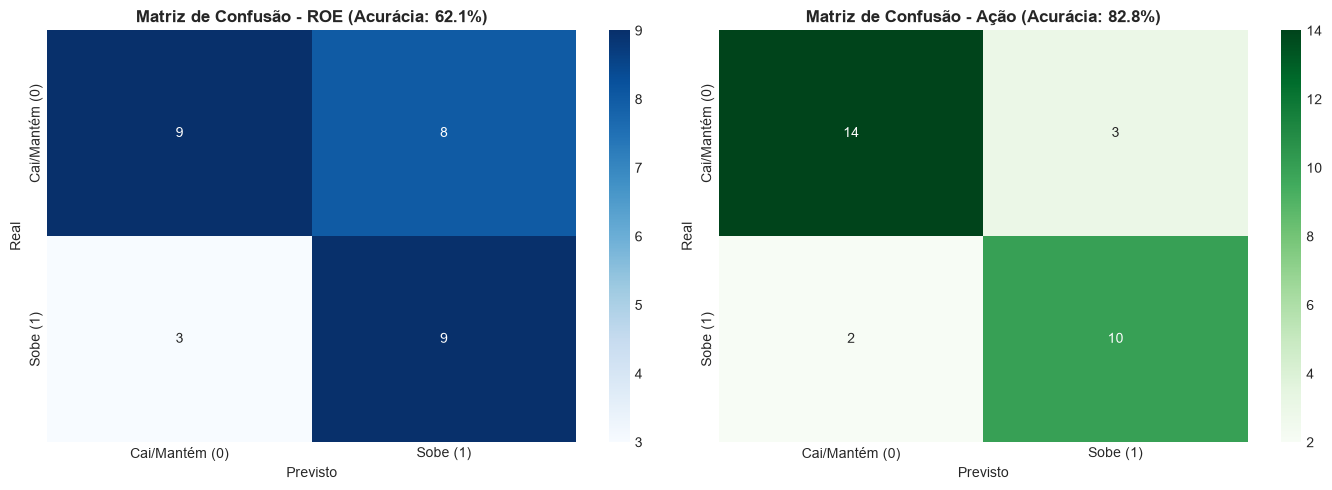

In [20]:
# Matrizes de Confusão Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz 1: ROE
cm_roe = confusion_matrix(y_test_roe, y_pred_roe)
sns.heatmap(cm_roe, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Cai/Mantém (0)', 'Sobe (1)'],
            yticklabels=['Cai/Mantém (0)', 'Sobe (1)'])
axes[0].set_title(f'Matriz de Confusão - ROE (Acurácia: {acc_roe:.1%})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Previsto')

# Matriz 2: Ação
cm_acao = confusion_matrix(y_test_acao, y_pred_acao)
sns.heatmap(cm_acao, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Cai/Mantém (0)', 'Sobe (1)'],
            yticklabels=['Cai/Mantém (0)', 'Sobe (1)'])
axes[1].set_title(f'Matriz de Confusão - Ação (Acurácia: {acc_acao:.1%})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Previsto')

plt.tight_layout()
plt.show()

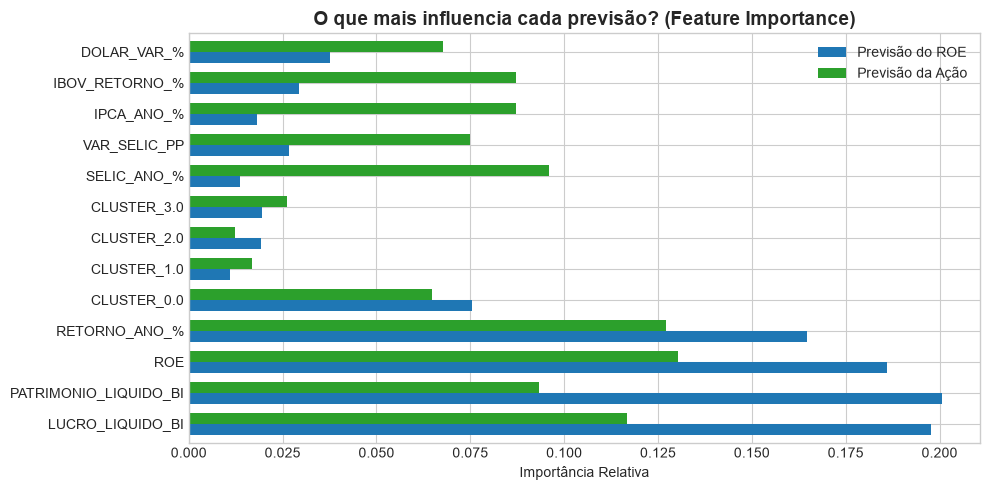

In [21]:
# Comparação de Feature Importances (O que move o ROE vs o que move o Preço?)
importances_roe = modelo_roe.named_steps['classifier'].feature_importances_
importances_acao = modelo_acao.named_steps['classifier'].feature_importances_

df_imp = pd.DataFrame({
    'Feature': features,
    'Peso_para_ROE': importances_roe,
    'Peso_para_ACAO': importances_acao
}).set_index('Feature')

fig, ax = plt.subplots(figsize=(10, 5))
df_imp.plot(kind='barh', ax=ax, color=['#1f77b4', '#2ca02c'], width=0.7)
ax.set_title('O que mais influencia cada previsão? (Feature Importance)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância Relativa')
ax.set_ylabel('')
plt.legend(['Previsão do ROE', 'Previsão da Ação'])
plt.tight_layout()
plt.show()

In [22]:
# Criar DataFrame com o resultado do Teste
df_resultado = X_test.copy()
df_resultado['TICKER'] = df_modelo.loc[idx_test, 'TICKER']
df_resultado['ANO'] = df_modelo.loc[idx_test, 'ANO']

# Sinais Reais vs Previstos
df_resultado['ROE_SOBE_REAL'] = y_test_roe.values
df_resultado['ROE_SOBE_PREV'] = y_pred_roe
df_resultado['ACAO_SOBE_REAL'] = y_test_acao.values
df_resultado['ACAO_SOBE_PREV'] = y_pred_acao

# Cruzamento dos Cenários para tomada de decisão
def classificar_decisao(roe, acao):
    if roe == 1 and acao == 1:
        return 'Crescente (ROE Sobe, Ação Sobe)'
    elif roe == 0 and acao == 0:
        return 'Descrescente (ROE Cai, Ação Cai)'
    elif roe == 1 and acao == 0:
        return 'Oportunidade (ROE Sobe, Ação Cai)'
    else:
        return 'Especulação (ROE Cai, Ação Sobe)'

df_resultado['CENARIO_REAL'] = [classificar_decisao(r, a) for r, a in zip(df_resultado['ROE_SOBE_REAL'], df_resultado['ACAO_SOBE_REAL'])]
df_resultado['CENARIO_PREV'] = [classificar_decisao(r, a) for r, a in zip(df_resultado['ROE_SOBE_PREV'], df_resultado['ACAO_SOBE_PREV'])]

print("=== RESUMO DAS PREVISÕES NO CONJUNTO DE TESTE ===")
print(f"Acerto individual se ROE Sobe:   {acc_roe:.2%}")
print(f"Acerto individual se AÇÃO Sobe:  {acc_acao:.2%}")
print(f"Acerto da combinação de ambos:   {(df_resultado['CENARIO_REAL'] == df_resultado['CENARIO_PREV']).mean():.2%}\n")

# Visualizar as 15 primeiras previsões lado a lado
colunas_exibicao = ['TICKER', 'ANO', 'ROE_SOBE_REAL', 'ROE_SOBE_PREV', 'ACAO_SOBE_REAL', 'ACAO_SOBE_PREV', 'CENARIO_REAL', 'CENARIO_PREV']
df_resultado.groupby('ANO')[colunas_exibicao].head(15)

=== RESUMO DAS PREVISÕES NO CONJUNTO DE TESTE ===
Acerto individual se ROE Sobe:   62.07%
Acerto individual se AÇÃO Sobe:  82.76%
Acerto da combinação de ambos:   51.72%



,TICKER,ANO,ROE_SOBE_REAL,ROE_SOBE_PREV,ACAO_SOBE_REAL,ACAO_SOBE_PREV,CENARIO_REAL,CENARIO_PREV
83,RENT3.SA,2023,0,1,0,0,"Descrescente (ROE Cai, Ação Cai)","Oportunidade (ROE Sobe, Ação Cai)"
4,ALOS3.SA,2023,1,1,0,1,"Oportunidade (ROE Sobe, Ação Cai)","Crescente (ROE Sobe, Ação Sobe)"
42,ENGI11.SA,2023,1,1,0,0,"Oportunidade (ROE Sobe, Ação Cai)","Oportunidade (ROE Sobe, Ação Cai)"
40,ENEV3.SA,2023,0,1,0,0,"Descrescente (ROE Cai, Ação Cai)","Oportunidade (ROE Sobe, Ação Cai)"
10,AURE3.SA,2024,0,1,1,1,"Especulação (ROE Cai, Ação Sobe)","Crescente (ROE Sobe, Ação Sobe)"
47,GGBR4.SA,2022,0,0,0,1,"Descrescente (ROE Cai, Ação Cai)","Especulação (ROE Cai, Ação Sobe)"
110,VIVT3.SA,2022,0,1,1,1,"Especulação (ROE Cai, Ação Sobe)","Crescente (ROE Sobe, Ação Sobe)"
36,CSNA3.SA,2024,0,1,1,0,"Especulação (ROE Cai, Ação Sobe)","Oportunidade (ROE Sobe, Ação Cai)"
70,PETR4.SA,2023,0,0,1,0,"Especulação (ROE Cai, Ação Sobe)","Descrescente (ROE Cai, Ação Cai)"
11,B3SA3.SA,2022,0,0,1,1,"Especulação (ROE Cai, Ação Sobe)","Especulação (ROE Cai, Ação Sobe)"
